# 3.20 Calibration -- VIS and NIR Flatfield

OVERVIEW: Observe an extended bright source to illuminate large portions of the array simultaneously. We plan to take repeat observations to illuminate different peices of the array because there is no one source that will illuminate it all. This task can be done at any time -- it does not depend on results from previous tasks.

DATA PRODUCTS:
- RD-A1: This data will be utilized to generate an in-flight VIS and NIR flat-field image

EXIT CRITERIA: observation obtained, analysis complete and summarized in 3.20_ResultsSummary.md
- Data with a TBD S/N or better is obtained for TBD% of the VIS detector and TBD% of the NIR detector

DATA VOLUME: data volume TBD based on how many observations are required and for what % of the array each time.

TARGET CRITERIA: bright extended source. 

KEY STAKEHOLDERS: Christina Hedges

## Load In

In [2]:
# ''' Make sure you have pandorasim installed and updated '''
import pandorasat as ps
import pandorasim as pp
ps.phoenix.get_phoenix_model(teff=7000, jmag=10) ### this is a temporary fix to an import error with pandorasim
from pandorasim import VisibleSim, NIRSim
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord, Longitude
from astropy.io import fits
from pandorasat.plotting import animate
from pandorasat.plotting import save_mp4, save_gif
from astropy.time import Time, TimeDelta

### Importing additional functions and constants used in this notebook
import sys, os
sys.path.append(os.path.abspath('..'))
from CommissFunctions import generate_task_plan 
from CommissFunctions import data_rate, bits_per_pix_VIS, compression_fractor_VIS, frame_time_VIS, stored_frames_per_int_VIS, pass_time_min, regions_NIR, bits_per_pix_NIR, compression_fractor_NIR, NIR_ra_shape, NIR_dec_shape

## Define Array Location Function

In [11]:
''' Function defining the target location on the array -- this may be needed to illuminate different regions'''
### This function returns a location to point the telescope [in degrees] given an observation id number.
# We will update this function to adjust the pattern based on input from the stakeholders.
# We currently assume that the "home" location is with our target in the center of the NIR array. 
# (ra, dec)=(10,10)deg is only a default for visualization in the next cell.
###

### Set the number of observations here
num_observations = 3 # this is currently arbitrary

def array_location(obsid_num, ra_home=10*u.degree, dec_home=10*u.degree):
    
    ra_home = ra_home
    dec_home = dec_home
    NIR_shape_deg = NIR_ra_shape.to(u.degree) ### Shape of the array in degrees. RA and Dec are the same.
    
    ### center 
    if obsid_num == 0 or obsid_num == 5: location = (ra_home, dec_home)
    
    offset = (NIR_shape_deg / 2) *0.2  ### 20% movement
    if obsid_num == 1: location = (ra_home-offset, dec_home+offset)
    if obsid_num == 2: location = (ra_home+offset, dec_home-offset)
    
    new_ra = location[0]
    new_dec = location[1]
    return (new_ra, new_dec)

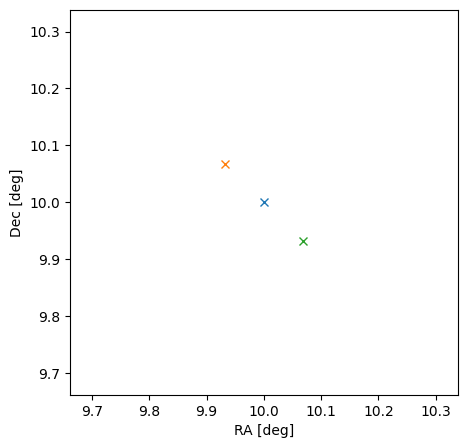

In [12]:
''' Plot the array location pattern on the VISDA array '''
### This is for visualizing the pattern, only. (10,10)deg is a default central location. See function above. 

plt.figure(figsize=(5, 5))
ax = plt.subplot()

for i in range(num_observations):
    loc = array_location(i) ### call the array_location() function above
    ax.plot(loc[0].value,loc[1].value, 'x')
    
plt.xlabel('RA [deg]')
plt.ylabel('Dec [deg]')

NIR_shape_deg = NIR_ra_shape.to(u.degree) ### set plot limits to the shape of VISDA
plt.xlim(10-(NIR_shape_deg.value/2), 10+(NIR_shape_deg.value/2))
plt.ylim(10-(NIR_shape_deg.value/2), 10+(NIR_shape_deg.value/2))

plt.show()

## Data Volume

BEN'S NOTE: If we have to tile across the FOV in order to get full coverage, it may be worthwhile to mosaic large science mode ROIs rather than take FFIs at a few pointings because the science ROIs can be coadded onboard.

(#) observations, simultaneous VIS and NIR. VIS observations are full frame images. NIR observations have increasing subarray sizes. 

NOTE: This set up is based on the Data Volume Spreadsheet, but it may be adjusted once the target is set.

In [13]:
''' Constants for this commissioning task '''
regions_VIS            = 1
VIS_xpix               = 1024  # 2048
VIS_ypix               = 1024  # 2048
frames_per_int_VIS     = 50
bits_per_int_VIS       = VIS_xpix * VIS_ypix * regions_VIS * bits_per_pix_VIS * stored_frames_per_int_VIS
int_and_reset_time_VIS = frame_time_VIS * frames_per_int_VIS
bits_per_sec_VIS       = bits_per_int_VIS / int_and_reset_time_VIS
bits_per_sec_comp_VIS  = bits_per_sec_VIS / compression_fractor_VIS

BEN'S NOTE: Why are each of the observation locations different numbers of integrations?

In [14]:
''' VIS Observations '''

##### VIS Observation 1 #####
num_int_VIS1            = 100
test_time_VIS1          = num_int_VIS1 * int_and_reset_time_VIS
bits_test_total_VIS1    = bits_per_sec_comp_VIS * test_time_VIS1
Gbits_test_packet_VIS1  = bits_test_total_VIS1 / 1E9 * 1.1 * 1.25
downlinks_VIS1          = Gbits_test_packet_VIS1 * 1E9 / (data_rate * 1E6) /60 /pass_time_min 

print('VIS Observation 1:', Gbits_test_packet_VIS1, 'Gbits')


##### VIS Observation 2 #####
num_int_VIS2            = 226
test_time_VIS2          = num_int_VIS2 * int_and_reset_time_VIS
bits_test_total_VIS2    = bits_per_sec_comp_VIS * test_time_VIS2
Gbits_test_packet_VIS2  = bits_test_total_VIS2 / 1E9 * 1.1 * 1.25
downlinks_VIS2          = Gbits_test_packet_VIS2 * 1E9 / (data_rate * 1E6) /60 /pass_time_min 

print('VIS Observation 2:', Gbits_test_packet_VIS2, 'Gbits')


##### VIS Observation 3 #####
num_int_VIS3            = 304
test_time_VIS3          = num_int_VIS3 * int_and_reset_time_VIS
bits_test_total_VIS3    = bits_per_sec_comp_VIS * test_time_VIS3
Gbits_test_packet_VIS3  = bits_test_total_VIS3 / 1E9 * 1.1 * 1.25
downlinks_VIS3          = Gbits_test_packet_VIS3 * 1E9 / (data_rate * 1E6) /60 /pass_time_min 

print('VIS Observation 3:', Gbits_test_packet_VIS3, 'Gbits')


VIS Observation 1: 1.537911466666667 Gbits
VIS Observation 2: 3.475679914666667 Gbits
VIS Observation 3: 4.675250858666667 Gbits


In [28]:
''' NIR Observations '''

#### NIR Observation 1 ####
NIR_xpix_NIR1              = 84
NIR_ypix_NIR1              = 400
stored_frames_per_int_NIR1 = 24
frames_per_int_NIR1        = 24 
num_int_NIR1               = 120
frame_time_NIR1            = NIR_xpix_NIR1 * NIR_ypix_NIR1 * 0.00001 #sec
int_and_reset_time_NIR1    = frame_time_NIR1 * (frames_per_int_NIR1+1)
bits_per_int_NIR1          = NIR_xpix_NIR1 * NIR_ypix_NIR1 * regions_NIR * bits_per_pix_NIR * stored_frames_per_int_NIR1
bits_per_sec_NIR1          = bits_per_int_NIR1 / int_and_reset_time_NIR1
test_time_NIR1             = num_int_NIR1 * int_and_reset_time_NIR1
bits_per_sec_comp_NIR1     = bits_per_sec_NIR1 / compression_fractor_NIR
bits_test_total_NIR1       = bits_per_sec_comp_NIR1 * test_time_NIR1
Gbits_test_packet_NIR1     = bits_test_total_NIR1 / 1E9 * 1.1 * 1.25
downlinks_NIR1             = Gbits_test_packet_NIR1 * 1E9 / (data_rate * 1E6) /60 /pass_time_min

print('NIR Observation 1:', Gbits_test_packet_NIR1, 'Gbits')


#### NIR Observation 2 ####
NIR_xpix_NIR2              = 516
NIR_ypix_NIR2              = 2048
stored_frames_per_int_NIR2 = 6
frames_per_int_NIR2        = 6 
num_int_NIR2               = 30
frame_time_NIR2            = NIR_xpix_NIR2 * NIR_ypix_NIR2 * 0.00001 #sec
int_and_reset_time_NIR2    = frame_time_NIR2 * (frames_per_int_NIR2+1)
bits_per_int_NIR2          = NIR_xpix_NIR2 * NIR_ypix_NIR2 * regions_NIR * bits_per_pix_NIR * stored_frames_per_int_NIR2
bits_per_sec_NIR2          = bits_per_int_NIR2 / int_and_reset_time_NIR2
test_time_NIR2             = num_int_NIR2 * int_and_reset_time_NIR2
bits_per_sec_comp_NIR2     = bits_per_sec_NIR2 / compression_fractor_NIR
bits_test_total_NIR2       = bits_per_sec_comp_NIR2 * test_time_NIR2
Gbits_test_packet_NIR2     = bits_test_total_NIR2 / 1E9 * 1.1 * 1.25
downlinks_NIR2             = Gbits_test_packet_NIR2 * 1E9 / (data_rate * 1E6) /60 /pass_time_min

print('NIR Observation 2:', Gbits_test_packet_NIR2, 'Gbits')


#### NIR Observation 3 ####
NIR_xpix_NIR3              = 2048
NIR_ypix_NIR3              = 2048
stored_frames_per_int_NIR3 = 6
frames_per_int_NIR3        = 6 
num_int_NIR3               = 10
frame_time_NIR3            = NIR_xpix_NIR3 * NIR_ypix_NIR3 * 0.00001 #sec
int_and_reset_time_NIR3    = frame_time_NIR3 * (frames_per_int_NIR3+1)
bits_per_int_NIR3          = NIR_xpix_NIR3 * NIR_ypix_NIR3 * regions_NIR * bits_per_pix_NIR * stored_frames_per_int_NIR3
bits_per_sec_NIR3          = bits_per_int_NIR3 / int_and_reset_time_NIR3
test_time_NIR3             = num_int_NIR3 * int_and_reset_time_NIR3
bits_per_sec_comp_NIR3     = bits_per_sec_NIR3 / compression_fractor_NIR
bits_test_total_NIR3       = bits_per_sec_comp_NIR3 * test_time_NIR3
Gbits_test_packet_NIR3     = bits_test_total_NIR3 / 1E9 * 1.1 * 1.25
downlinks_NIR3             = Gbits_test_packet_NIR3 * 1E9 / (data_rate * 1E6) /60 /pass_time_min

print('NIR Observation 3:', Gbits_test_packet_NIR3, 'Gbits')

NIR Observation 1: 1.0644480000000003 Gbits
NIR Observation 2: 2.09240064 Gbits
NIR Observation 3: 2.76824064 Gbits


### Total data volume

In [29]:
### Total data volume for all three parts
Gbits_total = (Gbits_test_packet_VIS1+Gbits_test_packet_NIR1) + (Gbits_test_packet_VIS2+Gbits_test_packet_NIR2) + (Gbits_test_packet_VIS3+Gbits_test_packet_NIR3)
downlinks_total = (downlinks_VIS1+downlinks_NIR1) + (downlinks_VIS2+downlinks_NIR2) + (downlinks_VIS3+downlinks_NIR3)
test_time_total = max([test_time_VIS1, test_time_NIR1]) + max([test_time_VIS2, test_time_NIR2]) + max([test_time_VIS3, test_time_NIR3])

print('Test time, total, no slew/overhead time:', test_time_total/60/60, 'hours')
print('Volume, total:', Gbits_total, 'Gbits')
print('Downlinks, total:', downlinks_total)

Test time, total, no slew/overhead time: 1.7522222222222223 hours
Volume, total: 15.613931520000001 Gbits
Downlinks, total: 6.5058048


In [30]:
### Adding important variables to a dictionary for later
obs_dict = {
    'VIS1': {'test_time': test_time_VIS1, 'num_int': num_int_VIS1},
    'VIS2': {'test_time': test_time_VIS2, 'num_int': num_int_VIS2},
    'VIS3': {'test_time': test_time_VIS3, 'num_int': num_int_VIS3},
    
    'NIR1': {'test_time': test_time_NIR1, 'xpix': NIR_xpix_NIR1, 'ypix': NIR_ypix_NIR1, 'frames_per_int': frames_per_int_NIR1, 'num_int': num_int_NIR1},
    'NIR2': {'test_time': test_time_NIR2, 'xpix': NIR_xpix_NIR2, 'ypix': NIR_ypix_NIR2, 'frames_per_int': frames_per_int_NIR2, 'num_int': num_int_NIR2},
    'NIR3': {'test_time': test_time_NIR3, 'xpix': NIR_xpix_NIR3, 'ypix': NIR_ypix_NIR3, 'frames_per_int': frames_per_int_NIR3, 'num_int': num_int_NIR3}
}

## The rest of this notebook should be run for each of the (#) observations. Select an observation number

In [15]:
observation_number = 0  

### For now, based on teh data-spreadsheet, we assume 3 observations. But this is likely to change. 
if observation_number == 0: 
    vis='VIS1'
    nir='NIR1'
elif observation_number == 1: 
    vis='VIS2'
    nir='NIR2'
elif observation_number == 2: 
    vis='VIS3'
    nir='NIR3'

## Define Target

In [18]:
### Posible Targets:
# ...
# ...
# ...
# ...
target = "M81"
c = SkyCoord(148.8882228621, 69.0652948201, unit="deg")

In [33]:
for i in range(num_observations):
    observation_number = i
    print('Running observation ' + str(observation_number))

    vis = 'VIS1'
    nir = 'NIR2'

    start_time = Time.now() # starting now. This should get overridden by the scheduler. 
    test_time = max(obs_dict[vis]['test_time'], obs_dict[nir]['test_time'])
    time_delta = TimeDelta(test_time, format='sec')
    end_time = start_time + time_delta

    # simVIS = VisibleSim(ROI_size=(VIS_xpix, VIS_ypix), nROIs=regions_VIS) 
    # simNIR = NIRSim()

    ''' Define the center of our observation based on target location and observation number '''
    location   = array_location(observation_number, c.ra, c.dec)
    ra0        = location[0] 
    dec0       = location[1] 
    theta0     = 0*u.deg


    ''' Point the simulator to the corrected location '''
    ###        RA,   DEC,    Theta 
    # simVIS.point(ra0, dec0, theta0)
    # simNIR.point(ra0, dec0, theta0)

    # hdulist_vis = simVIS.observe(nreads=frames_per_int_VIS, bin_frames=1, nframes=int(obs_dict[vis]['num_int']/reduction), start_time=start_time)
    # hdulist_nir = simNIR.observe(SC_ReadFrames=obs_dict[nir]['frames_per_int'], SC_Integrations=obs_dict[nir]['num_int'], start_time=start_time)


    ''' Save our simulated observation in a fits file '''
    # targ = target.replace(" ", "")
    # VISrois_outfile = "3.20_VISrois_"+str(targ)+"_obs"+str(observation_number)+".fits"
    # NIRrois_outfile = "3.20_NIRrois_"+str(targ)+"_obs"+str(observation_number)+".fits"
    # hdulist_vis.writeto(VISrois_outfile, overwrite=True)
    # hdulist_nir.writeto(NIRrois_outfile, overwrite=True)

    variables = {
        'visit_id': '0320', ### setting based on task number. Could change. 
        'obs_id': f"{observation_number:03}", ### setting based on observation number. 
        'target': target, 
        'priority': 1, ### all commissioning is priority 1
        'start_time': start_time, 
        'stop_time': end_time, 
        'RA': ra0,
        'DEC': dec0,
        'ffi_flag': 1, 
        
        'NIR_AvgGroups': 2, ### check what this is
        'NIR_ROI_StartX': int(2048 - obs_dict[nir]['xpix']), 
        'NIR_ROI_StartY': int(1024 - (obs_dict[nir]['ypix'] / 2) + 1), 
        'NIR_ROI_SizeX': obs_dict[nir]['xpix'], 
        'NIR_ROI_SizeY': obs_dict[nir]['ypix'],
        'NIR_SC_Resets1': 1,
        'NIR_SC_Resets2': 1, 
        'NIR_SC_DropFrames1': 0,
        'NIR_SC_DropFrames2': 16,
        'NIR_SC_DropFrames3': 0, 
        'NIR_SC_ReadFrames': obs_dict[nir]['frames_per_int'],
        'NIR_targetID': target, 
        'NIR_SC_Groups': 2,
        'NIR_SC_Integrations': obs_dict[nir]['num_int'], 
        
        'VIS_StarRoiDetMethod': 0,  ### 0: monitor stars at positions defined in [PredefinedStarRoiRa, PredefinedStarRoiDec]. 1: Run star detection algorithm on first image and obtain star ROIs from results.
        'VIS_FramesPerCoadd': frames_per_int_VIS, 
        'VIS_NumTotalFramesRequested': obs_dict[vis]['num_int'], 
        'VIS_TargetRA': ra0, 
        'VIS_TargetDEC': dec0, 
        'VIS_IncludeFieldSolnsInResp': 1, ### Determines whether the Ra/Dec/Rot values calculated for each frame in the visible science collect will be included in the response message [1] or not [0].
        'VIS_StarRoiDimension': VIS_xpix, 
        'VIS_MaxNumStarRois': 9, ### max number of star ROIs that will be used for coadding signal from target stars if StarRoiDetMethod == 1.
        'VIS_numPredefinedStarRois': regions_VIS, ### If StarRoiDetMethod==0, this is the number of [RA, DEC] coordinates contained in the PredefinedStarRoiRA and PredefinedStarRoiDEC vectors.
        'VIS_PredefinedStarRoiRa': '', ### currently defining as corner of ROI. We may update this to be ROI centers.
        'VIS_PredefinedStarRoiDec': '', 
        'VIS_targetID': target, 
        'VIS_NumExposuresMax': obs_dict[vis]['num_int'], 
        'VIS_ExposureTime_us': frame_time_VIS * 1000000  
    }

    output_soc_file = variables['visit_id']+'_'+variables['obs_id']+'_SOC.xml' 
    generate_task_plan(variables, output_soc_file)

Running observation 0
Running observation 1
Running observation 2


In [35]:
print(2048 - 1968)
print(int(1024 - (400 / 2)))

80
824


In [36]:
''' Finds target coordinates based on astropy '''
### You can do this differently as long as you have DEC and RA
# target = "GJ 3470"
# c = SkyCoord.from_name(target)


''' Identify the start time and end time of the observation '''
start_time = Time.now() # starting now. This should get overridden by the scheduler. 
test_time = max(obs_dict[vis]['test_time'], obs_dict[nir]['test_time'])
time_delta = TimeDelta(test_time, format='sec')
end_time = start_time + time_delta


''' Initialize a simulator object '''
### Set the number of ROIs and their sizes. 
### For now, NIRSim does not allow you to set the ROI_size. But we can still set it in the SOC file at the end.
simVIS = VisibleSim(ROI_size=(VIS_xpix, VIS_ypix), nROIs=regions_VIS) 
simNIR = NIRSim() # NIRSim(ROI_size=(obs_dict[nir]['xpix'], obs_dict[nir]['ypix']))

In [37]:
''' Define the center of our observation based on target location and observation number '''
location   = array_location(observation_number, c.ra, c.dec)
ra0        = location[0] 
dec0       = location[1] 
theta0     = 0*u.deg


''' Point the simulator to the corrected location '''
###        RA,   DEC,    Theta 
simVIS.point(ra0, dec0, theta0)
simNIR.point(ra0, dec0, theta0) ### this line has an known error. 

AttributeError: 'VisibleDetector' object has no attribute 'trace_pixel'

In [13]:
''' sim has various attributes you can print out '''
#print(sim.ra, sim.dec, sim.wcs)

''' Notably we have a Catalog of objects visable in the VIS FOV '''
cat = simVIS.source_catalog
#print(cat)

## Generate Simulated Observation

### VIS Observation

<Axes: title={'center': 'VISDA\n(RA:119.77 deg, Dec:15.39 deg, Roll:0.00 deg)'}, xlabel='Column [pixel]', ylabel='Row [pixel]'>

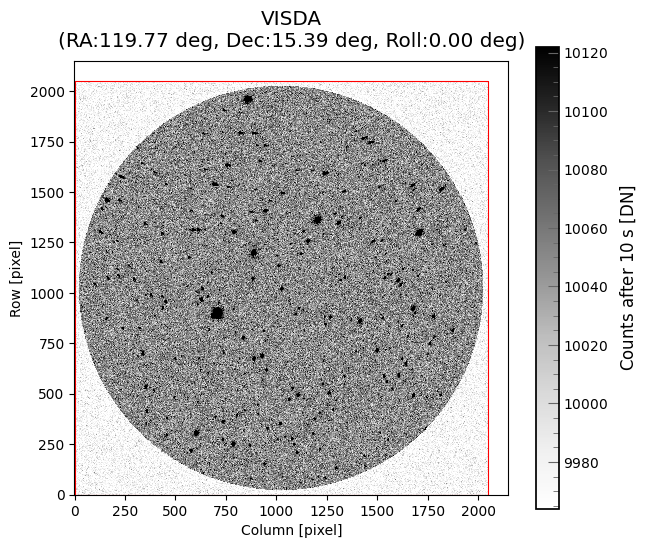

In [14]:
''' Plot the VIS Full Frame Image. ROIs are in red boxes defining the subarrays. '''
simVIS.show_FFI()

In [15]:
''' Create an Observation. '''
### This returns an astropy.io.fits.HDUList array. 
# `nreads` sets how many reads of the detector are coadded together to create a frame.
# `bin_frames` is a shortcut parameter to speed up computation. Must be a factor of nreads. We can ignore this for low nreads. 
# `nframes` sets how many frames will be returned.
# `start_time` indicates the time of observation. 
# `output_type` is set to array, for now. This make it easy to call, but we'll save it as a fits file later. 
###

### reduce the number of integrations to speed up calculations
reduction = 5 # set to 1 for no reduction
data = simVIS.observe(nreads=frames_per_int_VIS, bin_frames=1, nframes=int(obs_dict[vis]['num_int']/reduction), start_time=start_time, output_type="array")

### The shape is: (num ROIs, num frames, nrows, ncolumns)
data.shape

Modeling Pixel Positions: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [02:15<00:00,  7.98s/it]


(1, 20, 2048, 2048)

### NIR Observation

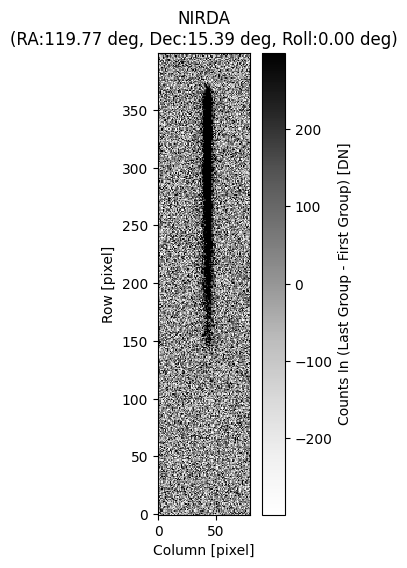

In [16]:
''' Plot the NIRDA subarray '''
simNIR.show_subarray();

In [17]:
''' Create a NIRDA observation. '''
### This returns an astropy.io.fits.HDUList array. The following parameters can be adjusted
# SC_Resets1 : Number of reset frames at the start of the first integration of exposure
# SC_Resets2 : Number of resent frames at the start of 1 through n integrations of exposure
# SC_DropFrames1 : Number of dropped frames after reset of any integration of exposure
# SC_DropFrames2 : Number of dropped frames in every group of integrations of exposure except the last group
# SC_DropFrames3 : Number of dropped frames in the last group of each integration of exposure
# SC_ReadFrames : Number of frames read during each group of integration of exposure
# SC_Groups : Number of groups per integration of exposure
# SC_Integrations : Number of integrations per exposure
# start_time : Time to start the observation. This is only used if returning a fits file, or supplying a flux function.
# noise : bool flag determining whether noise is simulated and included. Default is True.
# jitter : bool flag determining whether jitter is simulated and included. Default is True.
# output_type : String flag to determine the result output. Valid strings are "fits" or "array
###

ROIsize_override = (obs_dict[nir]['xpix'], obs_dict[nir]['ypix']) ### THIS CANNOT YET BE SPECIFIED IN sim.observe()

data = simNIR.observe(SC_ReadFrames=obs_dict[nir]['frames_per_int'], SC_Integrations=obs_dict[nir]['num_int'], start_time=start_time, output_type="array")

### The shape is: (num ROIs, num frames, nrows, ncolumns)
data.shape

Modeling Pixel Positions: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [04:46<00:00, 23.88s/it]


(120, 2, 400, 80)

## Save the Simulated Observation

In [18]:
''' Re-Create the observations in the correct format for the .fits file (i.e., output_type set to default) '''
### Before, object_type was array for easy computation in this notebook, but that is not correct for the .fits file
### This also includes the reduction
hdulist_vis = simVIS.observe(nreads=frames_per_int_VIS, bin_frames=1, nframes=int(obs_dict[vis]['num_int']/reduction), start_time=start_time)
hdulist_nir = simNIR.observe(SC_ReadFrames=obs_dict[nir]['frames_per_int'], SC_Integrations=obs_dict[nir]['num_int'], start_time=start_time)


''' Save our simulated observation in a fits file '''
targ = target.replace(" ", "")
VISrois_outfile = "3.20_VISrois_"+str(targ)+"_obs"+str(observation_number)+".fits"
NIRrois_outfile = "3.20_NIRrois_"+str(targ)+"_obs"+str(observation_number)+".fits"
hdulist_vis.writeto(VISrois_outfile, overwrite=True)
hdulist_nir.writeto(NIRrois_outfile, overwrite=True)

Modeling Pixel Positions: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [04:45<00:00, 23.77s/it]


In [19]:
### Show what is in our fits file: 
'''
Three FITS file extensions: 
    (1) PRIMARY: information about the simulated observation 
    (2) SCIENCE: data info, images
    (3) ROITABLE: VISDA pixel coordinates of the origin of the subarray, which is defined as the lower left corner
'''

hdul_rois = fits.open(VISrois_outfile) ### or NIRrois_outfile
print(hdul_rois.info())

#print('.')
#print('.')
#print('.')
#print('-- PRIMARY Headers --')
#print(hdul_rois[0].header)

#print('.')
#print('.')
#print('.')
#print('-- SCIENCE Headers --')
#print(hdul_rois[1].header)

#print('.')
#print('.')
#print('.')
#print('-- ROITABLE Headers --')
#print(hdul_rois[2].header)

Filename: 3.20_VISrois_GJ3470_obs0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   ()      
  1  SCIENCE       1 ImageHDU        71   (2048, 2048, 20)   int64   
  2  ROITABLE      1 BinTableHDU     22   2R x 1C   [D]   
None


## Data Products

### RD-A1: This data will be utilized to generate an in-flight VIS and NIR flat-field image

## Generate SOC File

In [ ]:
'''Here we define the information required for scheduling the observation.'''
### Some variables may be removed/added/changed. 
### The format and variables in the SOC files are currently be defined. 
### This function and variables should be revisited once the format is defined. 

variables = {
    'visit_id': '0320', ### setting based on task number. Could change. 
    'obs_id': f"{observation_number:03}", ### setting based on observation number. 
    'target': target, 
    'priority': 1, ### all commissioning is priority 1
    'start_time': start_time, 
    'stop_time': end_time, 
    'RA': ra0,
    'DEC': dec0,
    'ffi_flag': 1, 
    
    'NIR_AvgGroups': 2, ### check what this is
    'NIR_ROI_StartX': int(2048 - obs_dict[nir]['xpix']), 
    'NIR_ROI_StartY': int(1024 - (obs_dict[nir]['ypix'] / 2)), 
    'NIR_ROI_SizeX': obs_dict[nir]['xpix'], 
    'NIR_ROI_SizeY': obs_dict[nir]['ypix'],
    'NIR_SC_Resets1': 1,
    'NIR_SC_Resets2': 1, 
    'NIR_SC_DropFrames1': 0,
    'NIR_SC_DropFrames2': 16,
    'NIR_SC_DropFrames3': 0, 
    'NIR_SC_ReadFrames': obs_dict[nir]['frames_per_int'],
    'NIR_targetID': target, 
    'NIR_SC_Groups': 2,
    'NIR_SC_Integrations': obs_dict[nir]['num_int'], 
    
    'VIS_StarRoiDetMethod': 0,  ### 0: monitor stars at positions defined in [PredefinedStarRoiRa, PredefinedStarRoiDec]. 1: Run star detection algorithm on first image and obtain star ROIs from results.
    'VIS_FramesPerCoadd': frames_per_int_VIS, 
    'VIS_NumTotalFramesRequested': obs_dict[vis]['num_int'], 
    'VIS_TargetRA': ra0, 
    'VIS_TargetDEC': dec0, 
    'VIS_IncludeFieldSolnsInResp': 1, ### Determines whether the Ra/Dec/Rot values calculated for each frame in the visible science collect will be included in the response message [1] or not [0].
    'VIS_StarRoiDimension': [VIS_xpix, VIS_ypix], 
    'VIS_MaxNumStarRois': '', ### max number of star ROIs that will be used for coadding signal from target stars if StarRoiDetMethod == 1.
    'VIS_numPredefinedStarRois': regions_VIS, ### If StarRoiDetMethod==0, this is the number of [RA, DEC] coordinates contained in the PredefinedStarRoiRA and PredefinedStarRoiDEC vectors.
    'VIS_PredefinedStarRoiRa': '', ### currently defining as corner of ROI. We may update this to be ROI centers.
    'VIS_PredefinedStarRoiDec': '', 
    'VIS_targetID': target, 
    'VIS_NumExposuresMax': obs_dict[vis]['num_int'], 
    'VIS_ExposureTime_us': frame_time_VIS * 1000000  
}

In [21]:
'''Generate the SOC .xml file'''

output_soc_file = variables['visit_id']+'_'+variables['obs_id']+'_example_SOC.xml' 
generate_task_plan(variables, output_soc_file)